# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

In [ ]:
#@title Explanation Video
from IPython.display import HTML

HTML("""<video width="854" and height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Hackathon_Voice_based.mp4" type="video/mp4">
</video>
""")

# Hackathon: Voice commands based E-commerce ordering system
The goal of the hackathon is to train your model on different types of voice data (such as studio data and your own team data) and able to place order based on user preferences.

## Grading = 40 Marks

### **Objectives:**

Stage 0 - Obtain Features from Audio samples

Stage 1 (22 Marks) - Define and train a CNN model on Studio data and deploy the model in the server

Stage 2 (18 Marks) - Collect your voice samples (team data) and refine the classifier trained on Studio_data. Deploy the model in the server.

## Dataset Description

The data contains voice samples of classes - Zero, One, Two, Three, Four, Five. Each class is denoted by a numerical label from 0 to 5.

The audio files collected in a Studio dataset contain very few noise samples and all the files are in wav format.

The audio files recorded for the studio are saved with the following naming convention:

● Class Representation + user_id + sample_ID (or noise + sample_ID)

> For example: The voice sample by the user b2 recorded “Zero”, it is saved as 0_b2_35.wav. Here 35 is sample ID, 2 is the user id and ‘0’ is the label of that sample.




In [ ]:
#@title Please run the setup to download the dataset

from IPython import get_ipython
ipython = get_ipython()

notebook= "Hackathon2 - Voice E-commerce Ordering System" #name of the notebook

def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Hackathon_data/B17_studio_rev_data.zip")
    ipython.magic("sx unzip B17_studio_rev_data.zip ")
    print ("Setup completed successfully")

setup()

Setup completed successfully


In [ ]:
import os
import sys
import glob
import torch
import librosa
import warnings
import numpy as np
import torch.nn as nn
from time import sleep
from torch import optim
import torch.nn.functional as F
from torch.autograd import Variable
warnings.filterwarnings('ignore')

Audio data preprocessing

In [ ]:
import os
import shutil

source_folder = "./studio_data"
destination_folder = "./final_preprocess"

# Create destination folder
os.makedirs(destination_folder, exist_ok=True)
file_names=["5_b18_88.wav","5_b4_100.wav","5_b12_40.wav","2_n_b4_85.wav","3_n_b1_98.wav","2_b18_85.wav","5_n_g6_40.wav","5_n_g23_100.wav","3_G7_26.wav","0_b2_93.wav","5_b18_112.wav","2_n_g15_97.wav","5_b18_16.wav","5_b21_100.wav","5_n_b1_100.wav","5_n_g18_28.wav","2_n_g16_37.wav","4_G8_39.wav","0_n_g6_81.wav","5_n_g18_16.wav","5_n_g5_28.wav","5_n_g10_28.wav","0_n_b7_21.wav","3_G15_2.wav","3_n_g4_26.wav","5_b13_28.wav","5_a1_88.wav","3_n_g22_2.wav","2_n_g21_13.wav","5_G7_4.wav","5_G17_100.wav","5_G7_16.wav","4_n_g20_3.wav","5_b5_4.wav","3_b15_26.wav","4_G7_3.wav","2_b18_61.wav","3_r3_3.wav","5_g42_28.wav","0_b7_57.wav","2_a1_25.wav","5_G14_28.wav","5_b16_52.wav","4_n_b3_99.wav","5_n_g11_28.wav","3_n_g7_26.wav","2_n_g16_109.wav","4_n_g4_75.wav","2_n_g17_25.wav","2_g40_61.wav","5_n_g16_88.wav","5_n_g19_52.wav","4_b2_51.wav","5_b13_52.wav","3_b21_50.wav","5_G14_16.wav","2_n_b4_97.wav","5_g38_40.wav","4_n_g13_51.wav","5_b13_64.wav","3_G17_98.wav","5_b9_64.wav","3_G4_38.wav","4_b9_87.wav","3_n_g8_110.wav","4_b12_75.wav","4_b21_87.wav","0_n_g8_21.wav","4_n_g16_15.wav","5_G7_28.wav","0_b9_21.wav","5_b18_4.wav","5_n_b7_52.wav","3_n_g19_98.wav","5_n_g23_76.wav","5_g42_52.wav","5_b18_52.wav","2_n_g6_73.wav","5_b15_40.wav","4_b12_63.wav","3_n_g10_86.wav","4_b18_15.wav","3_G9_110.wav","4_n_g17_87.wav"]
moved = []
not_found = []

for filename in file_names:

    source_path = os.path.join(source_folder, filename)
    destination_path = os.path.join(destination_folder, filename)

    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
        moved.append(filename)
    else:
        not_found.append(filename)

print("========== SUMMARY ==========")
print("Requested :", len(file_names))
print("Moved     :", len(moved))
print("Not found :", len(not_found))

if not_found:
    print("\nFiles not found:")
    for filename in not_found:
        print(filename)

In [ ]:
import os
import glob
import pandas as pd

# Path to the studio_data folder
studio_data_path = './studio_data'

# List all .wav files in the studio_data directory
wav_files = glob.glob(os.path.join(studio_data_path, '*.wav'))

# Prepare lists to store extracted data
data = []

for filepath in wav_files:
    filename = os.path.basename(filepath)
    # Example filename: 0_b2_35.wav
    parts = filename.split('_')

    if len(parts) >= 3: # Ensure enough parts to extract class and user_id
        class_label = parts[0]
        user_id = parts[1]
        sample_id = parts[2].split('.')[0] # Remove .wav extension
        data.append({'class': class_label, 'user_id': user_id, 'sample_id': sample_id})
    else:
        print(f"Skipping file due to unexpected naming convention: {filename}")

# Create a pandas DataFrame from the extracted data
df = pd.DataFrame(data)

# Calculate counts of samples per class and user_id
counts = df.groupby(['user_id', 'class']).size().unstack(fill_value=0)

print("Counts of samples per class and user_id:")
print(counts)

# Optionally, check if each user has data for all 5 classes (0-4 or 0-5 depending on definition)
# The example implies 0-5 (6 classes: Zero to Five)
expected_classes = [str(i) for i in range(6)] # Assuming classes '0' through '5'

# Check for missing classes per user
missing_classes_per_user = {}
for user in counts.index:
    user_classes = counts.loc[user].index.astype(str).tolist()
    missing = [c for c in expected_classes if c not in user_classes]
    if missing:
        missing_classes_per_user[user] = missing

if missing_classes_per_user:
    print("\nUsers with missing classes:")
    for user, missing in missing_classes_per_user.items():
        print(f"User {user} is missing data for classes: {', '.join(missing)}")
else:
    print("\nAll users have data for all expected classes (0-5).")

Counts of samples per class and user_id:
class        0    1    2    3    4    5
user_id                                
B1           0    1    0    0    0    0
G10         10   10   10    9   10   10
G11          8   10   10   10   10   10
G12         10   10   10   10   10   10
G13         10   10   10   10   10   10
G14          8    9    9    8    4    8
G15          9   10   10    9   10   10
G16          9    8    9    9   10   10
G17         10   10   10    9    9    9
G18          9   10   10    8   10   10
G19         10   10   10   10   10   10
G2          10   10   10   10   10   10
G3          10   10   10   10   10   10
G4           9   10   10    9    9   10
G5           9    9   10   10   10   10
G6          10   10   10   10   10   10
G7           9   10    9    8    7    7
G8          10   10   10    9    8   10
G9           9    9   10    9   10   10
R2           0    0    1    0    0    0
a1           7    8    8    8    8    6
a1           0    1    0    0    0    0

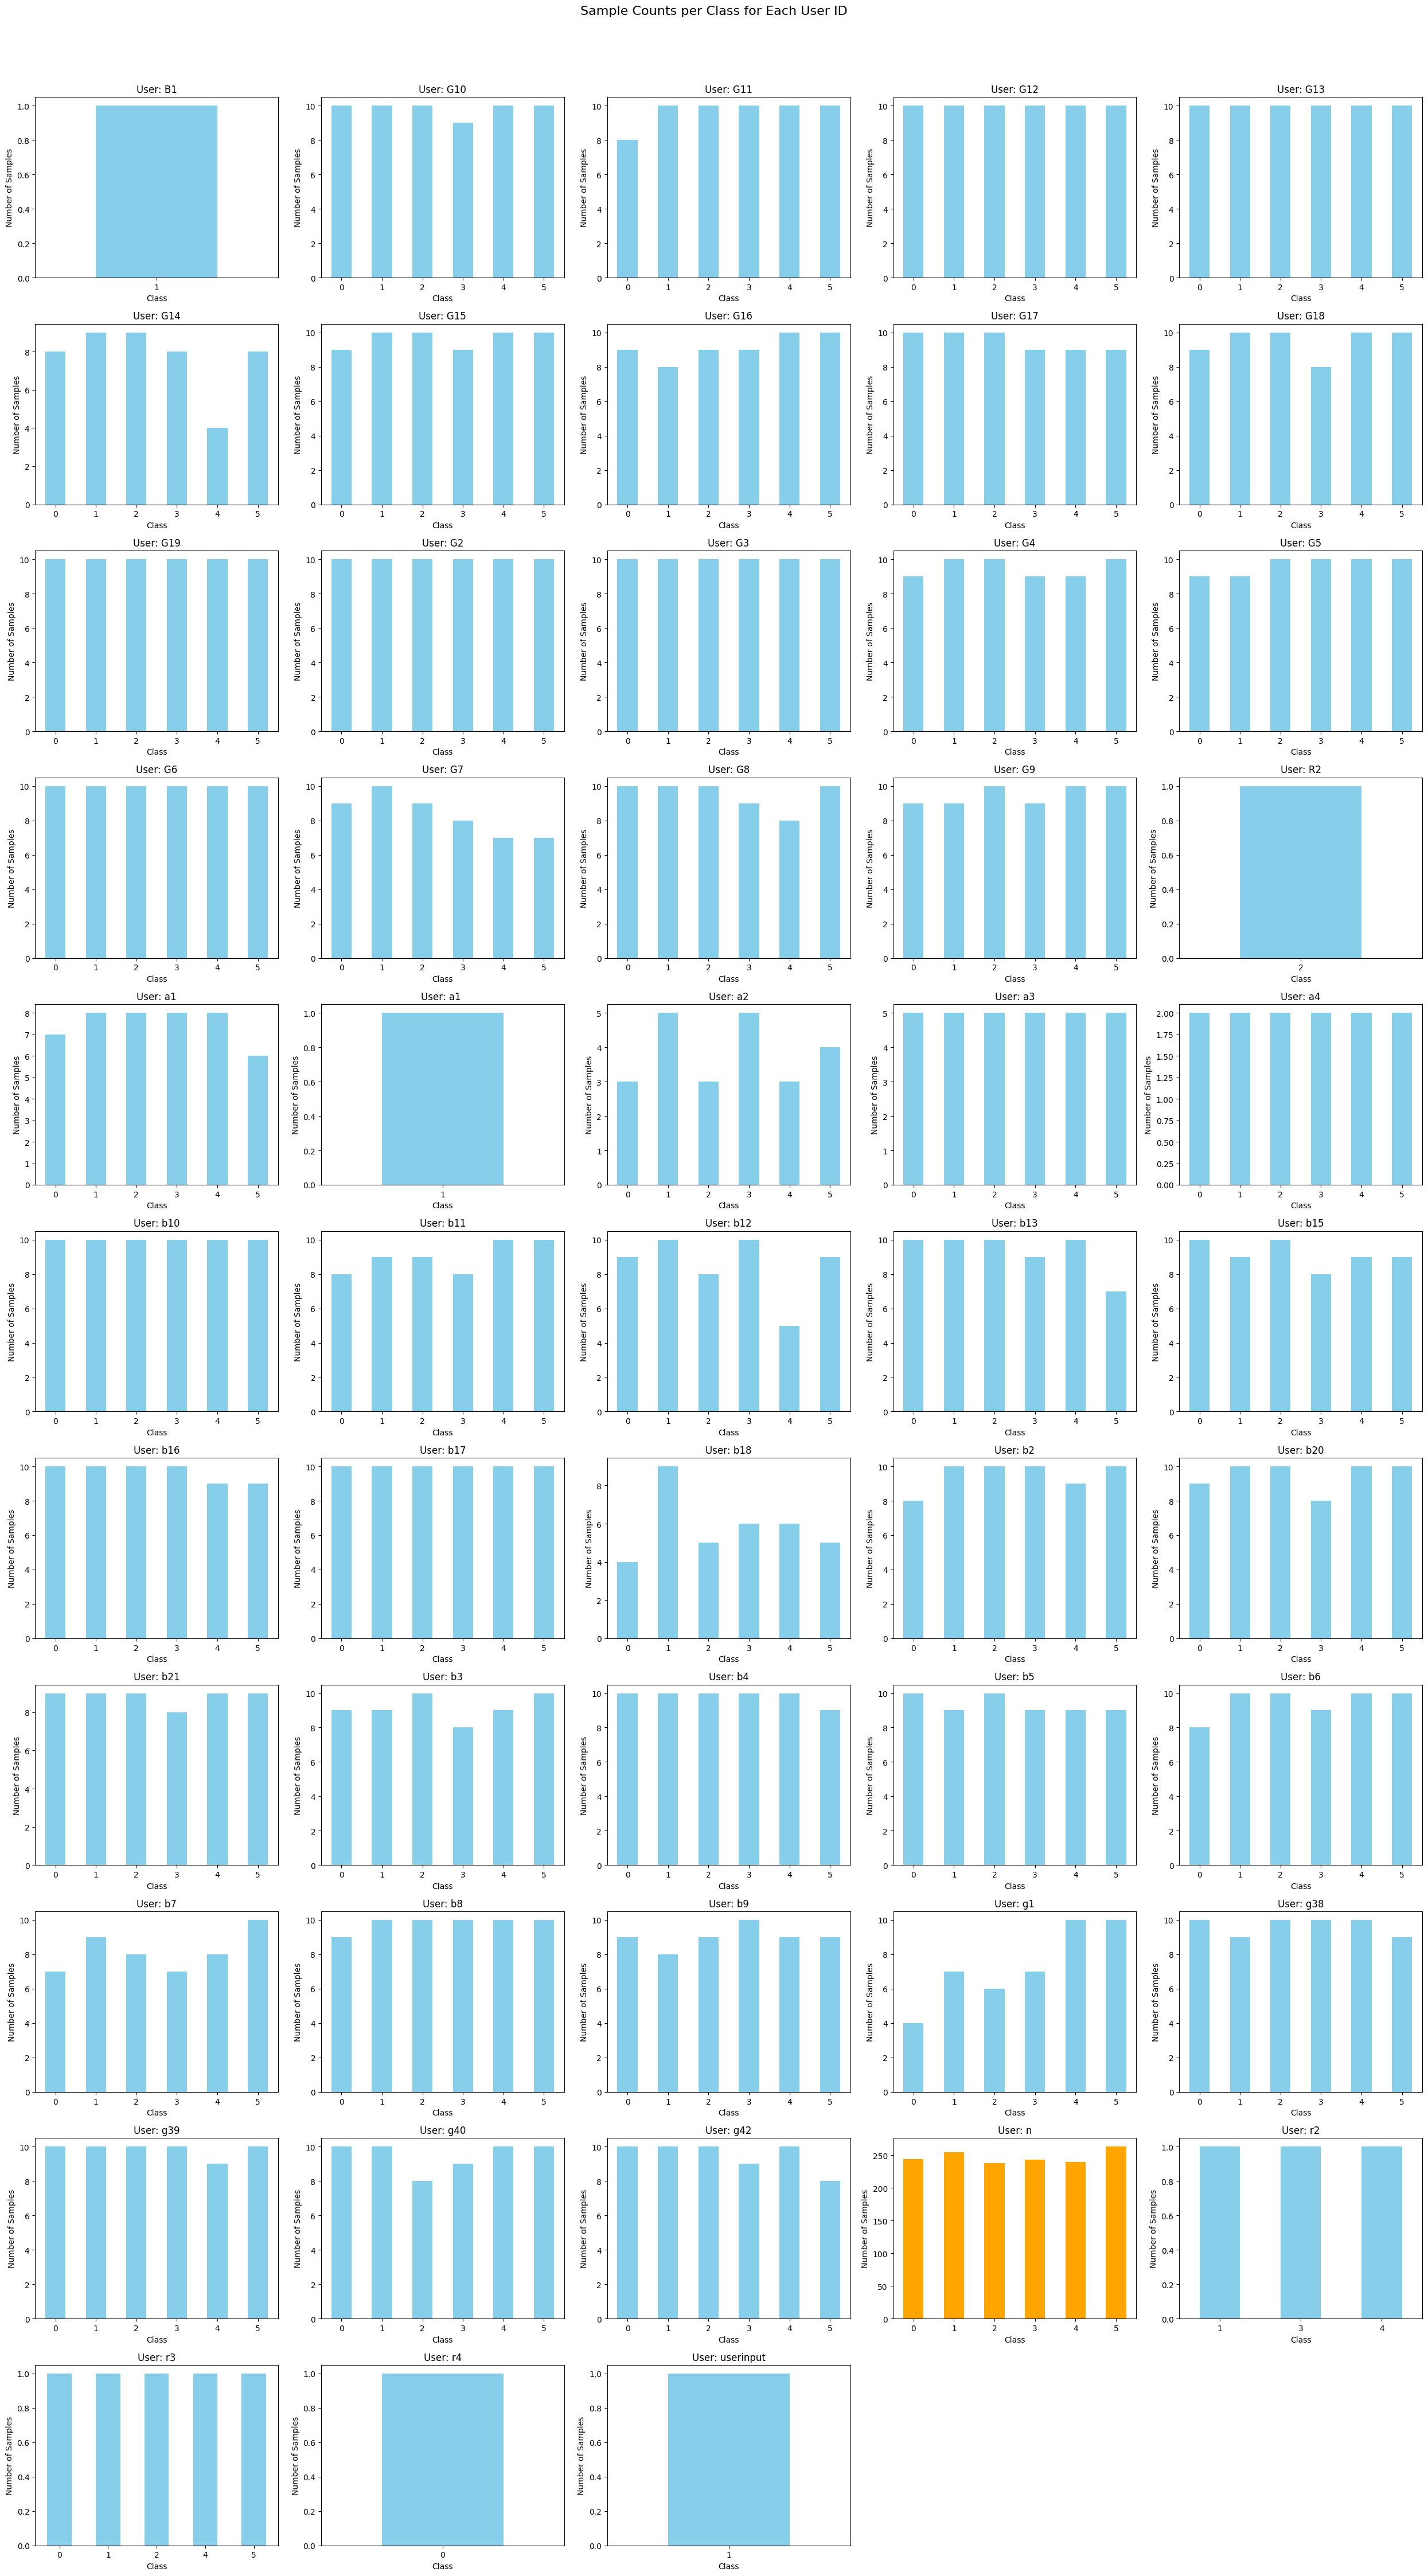

In [ ]:
import matplotlib.pyplot as plt
import math

# Assuming 'counts' DataFrame is available from the previous cell
# If not, you might need to re-run the previous cell or ensure 'counts' is globally accessible.

if 'counts' in locals() or 'counts' in globals():
    num_users = len(counts)
    ncols = 5 # Number of columns for subplots
    nrows = math.ceil(num_users / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    fig.suptitle('Sample Counts per Class for Each User ID', fontsize=16, y=1.02)
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, (user_id, row) in enumerate(counts.iterrows()):
        ax = axes[i]
        # Highlight user 'n' with a different color
        bar_color = 'skyblue'
        if user_id == 'n':
            bar_color = 'orange' # Distinct color for user 'n'

        row[row > 0].plot(kind='bar', ax=ax, color=bar_color) # Plot only classes with counts > 0
        ax.set_title(f'User: {user_id}')
        ax.set_xlabel('Class')
        ax.set_ylabel('Number of Samples')
        ax.tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal
        ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("Error: The 'counts' DataFrame was not found. Please run the previous cell first.")

Not important

In [ ]:
from IPython.display import Audio, display
import glob

for fp in sorted(glob.glob('/content/studio_data/0_G10_105.wav')):
    print(fp)
    display(Audio(fp))

/content/studio_data/0_G10_105.wav


Not important

Not important

### Distinguish truly silent files from noisy-but-real speech, then remove only the silent ones

Not important

### Retrain Stage 1 from scratch on the cleaned dataset

Since this changes the composition of `studio_data` itself (not just adding new samples), the fix only takes effect if you retrain from scratch — go back and **re-run your Stage 1 cells in order**, starting from `load_data('./studio_data')`, through the fresh `model = Net()` (a NEW, randomly-initialized model, not loading old weights), all the way through training, testing, and saving.

Do **not** load your previous `studio_model.pth`/`speech_model.t7` and fine-tune on top of it here -- those old weights were trained on the un-cleaned data, so any bias from the removed silent files is already baked into them. A clean retrain avoids inheriting that.

After retraining, regenerate the confusion matrix from earlier and check whether:
- silence no longer defaults to predicting "1"
- the 1↔5 and 2↔4 confusion pairs improved at all (they might not fully resolve from this alone, but worth checking)


## **Stage 0:** Obtain Features from Audio samples
---

### Generate features from an audio sample of '.wav' format
- Code is available to extract the features

In [ ]:
# Caution: Do not change the default parameters
def get_features(filepath, sr=8000, n_mfcc=30, n_mels=128, frames = 15):
    # The following function contains code to produce features of the audio sample.
    y, sr = librosa.load(filepath, sr=sr)
    D = np.abs(librosa.stft(y))**2
    S = librosa.feature.melspectrogram(S=D)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_S = librosa.power_to_db(S,ref=np.max)
    features = librosa.feature.mfcc(S=log_S, n_mfcc=n_mfcc)
    if features.shape[1] < frames :
        features = np.hstack((features, np.zeros((n_mfcc, frames - features.shape[1]))))
    elif features.shape[1] > frames:
        features = features[:, :frames]

    # Find 1st order delta_mfcc
    delta1_mfcc = librosa.feature.delta(features, order=1)

    # Find 2nd order delta_mfcc
    delta2_mfcc = librosa.feature.delta(features, order=2)

    # Stacking delta_mfcc features in sequence horizontally (column wise)
    #combined = np.hstack((features.flatten(),delta1_mfcc.flatten(), delta2_mfcc.flatten()))
    combined = np.hstack((delta1_mfcc.flatten(), delta2_mfcc.flatten()))

    # Increase the dimension by inserting an axis along second dimension
    combined = combined.flatten()[:,np.newaxis]

    # Convert the numpy.ndarray to a Tensor object
    combined = Variable(torch.from_numpy(combined)).float()
    return combined


All the voice samples needed for training are present in the folder `"studio_data"`

In [ ]:
%ls

B17_studio_rev_data.zip  label_audit_report.csv  studio_data/
final_preprocess/        sample_data/


##**Stage 1**:  Define and train a CNN model on Studio data and deploy the model in the server

---


### a) Extract features of Studio data (4 Marks)

 Load 'Studio data' and extract mfcc features

 **Evaluation Criteria:**

 * Complete the code in the load_data function
 * The function should take path of the folder containing audio samples as input
 * It should return features of all the audio samples present in the specified folder into single array (list of lists or 2-d numpy array) and their respective labels should be returned too

In [ ]:
def load_data(folder_path):
    """
    Loads all .wav files from folder_path, extracts MFCC-based features
    using get_features(), and pulls the class label out of the filename.

    Filenames look like: 0_b2_35.wav  -> label is the first token ("0")
    """
    features = []
    labels = []

    wav_files = glob.glob(os.path.join(folder_path, '*.wav'))
    print(f"Found {len(wav_files)} wav files in {folder_path}")

    for filepath in wav_files:
        filename = os.path.basename(filepath)
        label = int(filename.split('_')[0])          # class label is the first token
        feat = get_features(filepath)                  # tensor shape (900, 1)
        features.append(feat.numpy().flatten())         # flatten to (900,)
        labels.append(label)

    features = np.array(features)   # shape (N, 900)
    labels = np.array(labels)       # shape (N,)
    return features, labels


Load data from studio_data folder for extracting all features and labels

In [ ]:
studio_recorded_features, studio_recorded_labels = load_data('/content/studio_data')

Found 3895 wav files in /content/studio_data


Use train_test_split for splitting the train and test data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    studio_recorded_features,
    studio_recorded_labels,
    test_size=0.2,
    random_state=42,
    stratify=studio_recorded_labels
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (3116, 900) Test shape: (779, 900)


Load the dataset with DataLoader
- Refer to [torch.utils.data.TensorDataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.TensorDataset)
- Refer to [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Conv1d expects (batch, channels, length) -> we treat the 900 features as
# channels and use a sequence length of 1 (matches conv1's in_channels=900)
X_train_tensor = torch.from_numpy(X_train).float().unsqueeze(2)   # (N, 900, 1)
y_train_tensor = torch.from_numpy(y_train).long()

X_test_tensor = torch.from_numpy(X_test).float().unsqueeze(2)     # (N, 900, 1)
y_test_tensor = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Batches per epoch (train):", len(train_loader))


Batches per epoch (train): 195


### b) Define your CNN architecture (4 Marks)

[Hint](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html)

In [ ]:
print(model)

Net(
  (conv1): Conv1d(1350, 600, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(600, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (conv2): Conv1d(600, 400, kernel_size=(1,), stride=(1,))
  (bn2): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(400, 200, kernel_size=(1,), stride=(1,))
  (bn3): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (maxpool3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(200, 100, kernel_size=(1,), stride=(1,))
  (bn4): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (maxpool4): Ma

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1350, out_channels=600, kernel_size=1)  # 900 -> 1350
        self.bn1 = nn.BatchNorm1d(600)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool1d(1)
        self.dropout = nn.Dropout(p=0.4)

        self.conv2 = nn.Conv1d(in_channels=600, out_channels=400, kernel_size=1)
        self.bn2 = nn.BatchNorm1d(400)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool1d(1)

        self.conv3 = nn.Conv1d(in_channels=400, out_channels=200, kernel_size=1)
        self.bn3 = nn.BatchNorm1d(200)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool1d(1)


        self.conv4 = nn.Conv1d(in_channels=200, out_channels=100, kernel_size=1)
        self.bn4 = nn.BatchNorm1d(100)
        self.relu4 = nn.ReLU()
        self.maxpool4 = nn.MaxPool1d(1)


        self.fc1 = nn.Linear(100, 6)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout(out)

        out = self.conv4(out)
        out = self.bn4(out)
        out = self.relu4(out)
        out = self.maxpool4(out)
        out = self.dropout(out)

        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.logsoftmax(out)
        return out

In [ ]:
# To run the training on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
model = Net()
model = model.to(device)
print(model)

criterion = nn.NLLLoss()                                   # pairs with LogSoftmax output
optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer.zero_grad()        # Adam generally converges fastest here


Net(
  (conv1): Conv1d(1350, 600, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(600, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (maxpool1): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.4, inplace=False)
  (conv2): Conv1d(600, 400, kernel_size=(1,), stride=(1,))
  (bn2): BatchNorm1d(400, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (maxpool2): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(400, 200, kernel_size=(1,), stride=(1,))
  (bn3): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (maxpool3): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(200, 100, kernel_size=(1,), stride=(1,))
  (bn4): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (maxpool4): Ma

### c) Train and classify on the studio_data (3 Marks)

The goal here is to train the Model on voice samples collected in studio data and validate it continuously to calculate the loss and accuracy for the train dataset across each epoch.

Iterate over images in the train_loader and perform the following steps.

1. First, zero out the gradients using zero_grad()

2. Pass the data to the model. Convert the data to GPU before passing data  to the model

3. Calculate the loss using a Loss function

4. Perform Backward pass using backward() to update the weights

5. Optimize and predict by using the torch.max()

6. Calculate the accuracy of the train dataset


In [ ]:
num_epochs = 40

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()               # 1. zero out gradients
        output = model(data)                 # 2. forward pass
        loss = criterion(output, target)     # 3. compute loss
        loss.backward()                      # 4. backward pass
        optimizer.step()                     # 5. update weights

        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)  # 6. get predicted class
        correct += (predicted == target).sum().item()
        total += target.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Train Accuracy: {epoch_acc:.2f}%")


RuntimeError: Given groups=1, weight of size [600, 1350, 1], expected input[16, 900, 1] to have 1350 channels, but got 900 channels instead

### d) Testing Evaluation for CNN model (3 Marks)

Evaluate model with the given test data

1. Transform and load the test images.

2. Pass the test data through the model (network) to get the outputs

3. Get the predictions from a maximum value using torch.max

4. Compare with the actual labels and get the count of the correct labels

5. Calculate the accuracy based on the count of correct labels

### **Expected testing accuracy is above 80%**

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

test_accuracy = 100.0 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 86.91%


In [ ]:
# Paste as a new cell. Tests ONE audio file against your already-trained
# `model`, showing not just the predicted digit but the full confidence
# breakdown across all 6 classes -- this is what actually tells you whether
# cleaning helped, since a silent file will ALWAYS get assigned to some
# digit (LogSoftmax guarantees that) -- what matters is HOW confidently.

import torch
import numpy as np

def test_single_file(filepath, model, device):
    features = get_features(filepath)            # (900, 1)
    features = features.unsqueeze(0).to(device)   # (1, 900, 1) -- add batch dim

    model.eval()
    with torch.no_grad():
        output = model(features)          # log-probabilities, shape (1, 6)
        probs = torch.exp(output)         # convert LogSoftmax -> actual probabilities
        predicted = torch.argmax(output, dim=1).item()
        confidence = probs.max().item()

    print(f"File: {filepath}")
    print(f"Predicted digit: {predicted}")
    print(f"Confidence (top class probability): {confidence:.3f}")
    print(f"Uniform/random baseline would be: {1/6:.3f}")
    print()
    print("Full probability breakdown:")
    for digit, p in enumerate(probs[0].cpu().numpy()):
        bar = '#' * int(p * 50)
        print(f"  digit_{digit}: {p:.3f}  {bar}")

    return predicted, confidence, probs[0].cpu().numpy()


# --- Usage ---
# Point this at one of your known silent files (upload it first if it's
# not already on disk in this Colab session, e.g. via the Files panel).
silent_file_path = '/content/studio_data_excluded_silence/0_G7_105.wav'   # <-- change to your actual silent file's path

test_single_file(silent_file_path, model, device)

File: /content/studio_data_excluded_silence/0_G7_105.wav
Predicted digit: 2
Confidence (top class probability): 0.863
Uniform/random baseline would be: 0.167

Full probability breakdown:
  digit_0: 0.045  ##
  digit_1: 0.047  ##
  digit_2: 0.863  ###########################################
  digit_3: 0.010  
  digit_4: 0.014  
  digit_5: 0.021  #


(2,
 0.86277174949646,
 array([0.04508507, 0.04670511, 0.86277175, 0.00987856, 0.01410597,
        0.02145355], dtype=float32))

not Important

In [ ]:
# Confirms whether the classify_input() std-based guard (threshold=4.0)
# would actually catch THIS specific silent file, since it's a different
# clip than the two we originally calibrated the threshold on.

test_file = '/content/studio_data_excluded_silence/1_b5_12.wav'

feat = get_features(test_file)
feat_np = feat.detach().cpu().numpy()

feature_std = np.std(feat_np)
print(f"File: {test_file}")
print(f"Feature std: {feature_std:.3f}")
print(f"Guard threshold: 4.0")
print(f"Would be caught by guard: {feature_std < 4.0}")

File: /content/studio_data_excluded_silence/1_b5_12.wav
Feature std: 5.036
Guard threshold: 4.0
Would be caught by guard: False


not important

In [ ]:
stds = []
for fp in glob.glob('/content/studio_data_excluded_silence/*.wav'):
    feat = get_features(fp)
    stds.append(np.std(feat.detach().cpu().numpy()))

stds = np.array(stds)
print(f"Quarantined files: {len(stds)}")
print(f"std range: {stds.min():.3f} to {stds.max():.3f}")
print(f"Files that would slip PAST the guard (std >= 4.0): {(stds >= 4.0).sum()}")

Quarantined files: 322
std range: 0.444 to 5.036
Files that would slip PAST the guard (std >= 4.0): 11


not important

In [ ]:
# Part 1: identify exactly which 11 files slip past the guard, so you can
# spot-check by listening whether they're genuinely silent or were
# mistakenly quarantined (i.e. they actually contain faint real speech).

quarantine_stds = []
quarantine_files = []
for fp in glob.glob('/content/studio_data_excluded_silence/*.wav'):
    feat = get_features(fp)
    quarantine_stds.append(np.std(feat.detach().cpu().numpy()))
    quarantine_files.append(fp)

quarantine_stds = np.array(quarantine_stds)
quarantine_files = np.array(quarantine_files)

outlier_mask = quarantine_stds >= 4.0
outlier_files = quarantine_files[outlier_mask]
outlier_stds = quarantine_stds[outlier_mask]

order = np.argsort(-outlier_stds)  # highest std first (most likely to be real speech)
print("Files that slip past the guard (std >= 4.0), highest std first:")
for fp, s in zip(outlier_files[order], outlier_stds[order]):
    print(f"  {s:.3f}  {fp}")

print("\nListen to a few of these (especially the highest std ones) -- if they")
print("sound like real speech, they were mistakenly quarantined, not a guard gap.")


# Part 2: proper threshold calibration using FULL distributions, not just
# 2 examples. Compares std across ALL real training data vs ALL quarantined
# (silent) data, so you can pick a threshold based on where they actually
# separate -- not a guess.

real_stds = []
for fp in glob.glob('/content/studio_data/*.wav'):   # the CLEANED, kept files
    feat = get_features(fp)
    real_stds.append(np.std(feat.detach().cpu().numpy()))
real_stds = np.array(real_stds)

print(f"\n=== Full distribution comparison ===")
print(f"Real speech (n={len(real_stds)}):       "
      f"min={real_stds.min():.3f}  p5={np.percentile(real_stds,5):.3f}  "
      f"median={np.median(real_stds):.3f}")
print(f"Quarantined/silent (n={len(quarantine_stds)}): "
      f"max={quarantine_stds.max():.3f}  p95={np.percentile(quarantine_stds,95):.3f}  "
      f"median={np.median(quarantine_stds):.3f}")

# How many real speech files would get WRONGLY flagged at different thresholds?
for thresh in [4.0, 4.5, 5.0, 5.5]:
    false_positive_rate = (real_stds < thresh).mean()   # real speech caught by guard (bad)
    false_negative_rate = (quarantine_stds >= thresh).mean()  # silence that slips through (bad)
    print(f"\nThreshold={thresh}:")
    print(f"  Real speech wrongly flagged as silence: {false_positive_rate*100:.2f}%")
    print(f"  Silent files that slip past the guard:   {false_negative_rate*100:.2f}%")

Files that slip past the guard (std >= 4.0), highest std first:
  5.036  /content/studio_data_excluded_silence/1_b5_12.wav
  4.889  /content/studio_data_excluded_silence/0_b18_45.wav
  4.788  /content/studio_data_excluded_silence/2_G14_73.wav
  4.687  /content/studio_data_excluded_silence/0_g39_69.wav
  4.541  /content/studio_data_excluded_silence/4_b20_51.wav
  4.538  /content/studio_data_excluded_silence/5_n_g16_16.wav
  4.439  /content/studio_data_excluded_silence/5_b20_40.wav
  4.242  /content/studio_data_excluded_silence/3_b7_38.wav
  4.128  /content/studio_data_excluded_silence/0_n_b1_21.wav
  4.089  /content/studio_data_excluded_silence/0_b15_117.wav
  4.007  /content/studio_data_excluded_silence/1_b10_12.wav

Listen to a few of these (especially the highest std ones) -- if they
sound like real speech, they were mistakenly quarantined, not a guard gap.

=== Full distribution comparison ===
Real speech (n=3657):       min=1.161  p5=2.528  median=5.222
Quarantined/silent (n=322): 

In [ ]:
from IPython.display import Audio, display
import glob

for fp in sorted(glob.glob('/content/studio_data_excluded_silence/0_b15_117.wav')):
    print(fp)
    display(Audio(fp))

/content/studio_data_excluded_silence/0_b15_117.wav


In [ ]:
# Add this as a new cell right after your existing test-evaluation cell.
# It tells you EXACTLY what's being confused with what, instead of guessing.

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)
print("Confusion matrix (rows = true label, columns = predicted label):")
print(cm)
print()
print(classification_report(all_targets, all_preds, digits=3,
                             target_names=[f"digit_{i}" for i in range(6)]))

# Also print actual TRAIN split counts per class -- confirms whether stratify
# actually kept things balanced in YOUR specific split, not just overall.
import collections
print("\nTrain split class counts:", collections.Counter(y_train.tolist()))
print("Test split class counts: ", collections.Counter(y_test.tolist()))

Confusion matrix (rows = true label, columns = predicted label):
[[105   2   9   9   1   1]
 [  3 113   3   2   3  10]
 [  3   6 107   2   6   5]
 [  1   1   2 120   0   3]
 [  1   2   6   0 117   2]
 [  3   7   1   4   4 115]]

              precision    recall  f1-score   support

     digit_0      0.905     0.827     0.864       127
     digit_1      0.863     0.843     0.853       134
     digit_2      0.836     0.829     0.833       129
     digit_3      0.876     0.945     0.909       127
     digit_4      0.893     0.914     0.903       128
     digit_5      0.846     0.858     0.852       134

    accuracy                          0.869       779
   macro avg      0.870     0.869     0.869       779
weighted avg      0.869     0.869     0.869       779


Train split class counts: Counter({1: 538, 5: 533, 2: 518, 4: 510, 3: 509, 0: 508})
Test split class counts:  Counter({1: 134, 5: 134, 2: 129, 4: 128, 0: 127, 3: 127})


not important

Major preprocessing

In [ ]:
import os
import glob
import pandas as pd
from collections import Counter

# ============================================================
# LABEL AUDITOR
# ============================================================

# Change these paths if needed
DATA_DIRS = {
    "studio": "./studio_data",
   # "team": "./team_data"
}

VALID_LABELS = set(range(6))   # 0,1,2,3,4,5

audit_rows = []

for dataset_name, data_dir in DATA_DIRS.items():

    wav_files = glob.glob(os.path.join(data_dir, "*.wav"))

    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} DATA")
    print(f"{'='*60}")
    print(f"Total WAV files: {len(wav_files)}")

    for filepath in wav_files:

        filename = os.path.basename(filepath)

        # --------------------------------------------
        # Extract label exactly like your load_data()
        # --------------------------------------------
        try:
            first_part = filename.split("_")[0]
            filename_label = int(first_part)
        except (ValueError, IndexError):
            filename_label = None

        # --------------------------------------------
        # Validate label
        # --------------------------------------------
        if filename_label is None:
            status = "INVALID_FILENAME"

        elif filename_label not in VALID_LABELS:
            status = "INVALID_LABEL"

        else:
            status = "OK"

        audit_rows.append({
            "dataset": dataset_name,
            "filename": filename,
            "filepath": filepath,
            "filename_label": filename_label,
            "status": status
        })


# ============================================================
# CREATE AUDIT DATAFRAME
# ============================================================

audit_df = pd.DataFrame(audit_rows)

print("\nAudit completed.")
print(f"Total files checked: {len(audit_df)}")


# ============================================================
# 1. INVALID FILES
# ============================================================

invalid_df = audit_df[audit_df["status"] != "OK"]

print("\n" + "="*60)
print("INVALID / SUSPICIOUS FILENAMES")
print("="*60)

if len(invalid_df) == 0:
    print("No invalid filenames found.")
else:
    display(invalid_df)


# ============================================================
# 2. LABEL DISTRIBUTION
# ============================================================

print("\n" + "="*60)
print("LABEL DISTRIBUTION")
print("="*60)

label_distribution = (
    audit_df
    .dropna(subset=["filename_label"])
    .groupby(["dataset", "filename_label"])
    .size()
    .unstack(fill_value=0)
)

display(label_distribution)


# ============================================================
# 3. TOTAL DISTRIBUTION ACROSS ALL DATA
# ============================================================

print("\n" + "="*60)
print("TOTAL LABEL DISTRIBUTION")
print("="*60)

total_distribution = (
    audit_df["filename_label"]
    .value_counts()
    .sort_index()
)

print(total_distribution)


# ============================================================
# 4. DUPLICATE FILENAMES
# ============================================================

print("\n" + "="*60)
print("DUPLICATE FILENAMES")
print("="*60)

duplicates = audit_df[
    audit_df["filename"].duplicated(keep=False)
].sort_values("filename")

if len(duplicates) == 0:
    print("No duplicate filenames found.")
else:
    display(duplicates)


# ============================================================
# 5. SHOW ALL FILES LABELLED AS 1
# ============================================================

print("\n" + "="*60)
print("FILES LABELLED AS DIGIT 1")
print("="*60)

label_1_files = audit_df[
    audit_df["filename_label"] == 1
]

print(f"Number of files labelled 1: {len(label_1_files)}")

display(label_1_files.head(50))


# ============================================================
# 6. SHOW ALL FILES LABELLED AS 5
# ============================================================

print("\n" + "="*60)
print("FILES LABELLED AS DIGIT 5")
print("="*60)

label_5_files = audit_df[
    audit_df["filename_label"] == 5
]

print(f"Number of files labelled 5: {len(label_5_files)}")

display(label_5_files.head(50))


# ============================================================
# 7. SAVE AUDIT REPORT
# ============================================================

audit_df.to_csv("label_audit_report.csv", index=False)

print("\nAudit report saved as:")
print("label_audit_report.csv")


STUDIO DATA
Total WAV files: 3895

Audit completed.
Total files checked: 3895

INVALID / SUSPICIOUS FILENAMES
No invalid filenames found.

LABEL DISTRIBUTION


filename_label,0,1,2,3,4,5
dataset,,,,,,
studio,635,672,647,636,638,667



TOTAL LABEL DISTRIBUTION
filename_label
0    635
1    672
2    647
3    636
4    638
5    667
Name: count, dtype: int64

DUPLICATE FILENAMES
No duplicate filenames found.

FILES LABELLED AS DIGIT 1
Number of files labelled 1: 672


,dataset,filename,filepath,filename_label,status
0,studio,1_G4_84.wav,./studio_data/1_G4_84.wav,1,OK
1,studio,1_n_g10_36.wav,./studio_data/1_n_g10_36.wav,1,OK
3,studio,1_G4_60.wav,./studio_data/1_G4_60.wav,1,OK
5,studio,1_g42_0.wav,./studio_data/1_g42_0.wav,1,OK
15,studio,1_b10_0.wav,./studio_data/1_b10_0.wav,1,OK
16,studio,1_b17_84.wav,./studio_data/1_b17_84.wav,1,OK
20,studio,1_G14_48.wav,./studio_data/1_G14_48.wav,1,OK
27,studio,1_b10_24.wav,./studio_data/1_b10_24.wav,1,OK
28,studio,1_g38_36.wav,./studio_data/1_g38_36.wav,1,OK
30,studio,1_n_g2_96.wav,./studio_data/1_n_g2_96.wav,1,OK



FILES LABELLED AS DIGIT 5
Number of files labelled 5: 667


,dataset,filename,filepath,filename_label,status
6,studio,5_n_g17_4.wav,./studio_data/5_n_g17_4.wav,5,OK
9,studio,5_G14_76.wav,./studio_data/5_G14_76.wav,5,OK
10,studio,5_n_g10_100.wav,./studio_data/5_n_g10_100.wav,5,OK
22,studio,5_a2_29.wav,./studio_data/5_a2_29.wav,5,OK
23,studio,5_G19_52.wav,./studio_data/5_G19_52.wav,5,OK
32,studio,5_n_g11_64.wav,./studio_data/5_n_g11_64.wav,5,OK
36,studio,5_n_g5_88.wav,./studio_data/5_n_g5_88.wav,5,OK
44,studio,5_b17_4.wav,./studio_data/5_b17_4.wav,5,OK
45,studio,5_b13_112.wav,./studio_data/5_b13_112.wav,5,OK
49,studio,5_a1_28.wav,./studio_data/5_a1_28.wav,5,OK



Audit report saved as:
label_audit_report.csv


In [ ]:
# CELL 2: Load audio files for label auditing

import os
import pandas as pd
import IPython.display as ipd

# Path to your audio dataset
DATA_DIR = "./studio_data"

# Collect all WAV files
wav_files = []

for file in os.listdir(DATA_DIR):
    if file.lower().endswith(".wav"):
        filepath = os.path.join(DATA_DIR, file)

        # Label comes from the first character of filename
        filename_label = int(file.split("_")[0])

        wav_files.append({
            "filename": file,
            "filepath": filepath,
            "label": filename_label
        })

# Create DataFrame
audio_df = pd.DataFrame(wav_files)

print("Total WAV files:", len(audio_df))
print("\nLabel distribution:")
print(audio_df["label"].value_counts().sort_index())

audio_df.head()

Total WAV files: 3895

Label distribution:
label
0    635
1    672
2    647
3    636
4    638
5    667
Name: count, dtype: int64


,filename,filepath,label
0,1_G4_84.wav,./studio_data/1_G4_84.wav,1
1,1_n_g10_36.wav,./studio_data/1_n_g10_36.wav,1
2,3_G4_14.wav,./studio_data/3_G4_14.wav,3
3,1_G4_60.wav,./studio_data/1_G4_60.wav,1
4,3_b2_2.wav,./studio_data/3_b2_2.wav,3


In [ ]:
# CELL 3: Listen to a random audio file

sample = audio_df.sample(1).iloc[0]

print("Filename :", sample["filename"])
print("Label    :", sample["label"])
print("Filepath :", sample["filepath"])

display(ipd.Audio(sample["filepath"]))

Filename : 5_b10_40.wav
Label    : 5
Filepath : ./studio_data/5_b10_40.wav


Cell 4

In [ ]:
# ============================================================
# CELL 4: FIND POSSIBLE MISLABELLED AUDIO FILES
# ============================================================

import os
import pandas as pd
import torch
import torchaudio # Added this import

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

AUDIO_DIR = "./studio_data"

# Change this to your trained model
model.eval()

# ------------------------------------------------------------
# Get all WAV files
# ------------------------------------------------------------

wav_files = [
    os.path.join(AUDIO_DIR, f)
    for f in os.listdir(AUDIO_DIR)
    if f.lower().endswith(".wav")
]

print("Total WAV files:", len(wav_files))


# ------------------------------------------------------------
# Extract label from filename
# Example:
# 1_G4_84.wav  -> label = 1
# 5_b18_88.wav -> label = 5
# ------------------------------------------------------------

def get_filename_label(filepath):
    filename = os.path.basename(filepath)
    return int(filename.split("_")[0])


# ------------------------------------------------------------
# Predict each audio file
# ------------------------------------------------------------

results = []

for filepath in wav_files:

    filename = os.path.basename(filepath)
    true_label = get_filename_label(filepath)

    try:
        # Apply the SAME preprocessing used during training by calling get_features
        # get_features returns a tensor of shape (1350, 1)
        input_audio = get_features(filepath)

        # Add batch dimension and move to device
        # Model expects (batch, channels, length) so input_audio becomes (1, 1350, 1)
        input_audio = input_audio.unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            output = model(input_audio)

            predicted_label = torch.argmax(output, dim=1).item()

        results.append({
            "filename": filename,
            "filepath": filepath,
            "filename_label": true_label,
            "predicted_label": predicted_label,
            "match": true_label == predicted_label
        })

    except Exception as e:

        results.append({
            "filename": filename,
            "filepath": filepath,
            "filename_label": true_label,
            "predicted_label": None,
            "match": False,
            "error": str(e)
        })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

prediction_df = pd.DataFrame(results)

print("\nPrediction completed.")
print(prediction_df.head())


# ------------------------------------------------------------
# Find possible mislabels
# ------------------------------------------------------------

suspicious_df = prediction_df[
    prediction_df["filename_label"] != prediction_df["predicted_label"]
].copy()

print("\n============================================================")
print("POSSIBLE MISLABELLED FILES")
print("============================================================")

print("Total suspicious files:", len(suspicious_df))

display(suspicious_df.head(50))


# ------------------------------------------------------------
# Specifically check files labelled 1 but predicted as 5
# ------------------------------------------------------------

label_1_predicted_5 = suspicious_df[
    (suspicious_df["filename_label"] == 1) &
    (suspicious_df["predicted_label"] == 5)
]

print("\n============================================================")
print("FILES LABELLED 1 BUT MODEL PREDICTS 5")
print("============================================================")

print("Count:", len(label_1_predicted_5))

display(label_1_predicted_5)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

prediction_df.to_csv(
    "label_prediction_audit.csv",
    index=False
)

suspicious_df.to_csv(
    "suspicious_labels.csv",
    index=False
)

print("\nSaved:")
print("  label_prediction_audit.csv")
print("  suspicious_labels.csv")


Total WAV files: 3895

Prediction completed.
         filename                      filepath  filename_label  \
0     1_G4_84.wav     ./studio_data/1_G4_84.wav               1   
1  1_n_g10_36.wav  ./studio_data/1_n_g10_36.wav               1   
2     3_G4_14.wav     ./studio_data/3_G4_14.wav               3   
3     1_G4_60.wav     ./studio_data/1_G4_60.wav               1   
4      3_b2_2.wav      ./studio_data/3_b2_2.wav               3   

   predicted_label  match  
0                1   True  
1                1   True  
2                3   True  
3                1   True  
4                3   True  

POSSIBLE MISLABELLED FILES
Total suspicious files: 144


,filename,filepath,filename_label,predicted_label,match
9,5_G14_76.wav,./studio_data/5_G14_76.wav,5,1,False
19,0_G6_57.wav,./studio_data/0_G6_57.wav,0,2,False
76,2_n_b1_13.wav,./studio_data/2_n_b1_13.wav,2,1,False
170,5_b7_64.wav,./studio_data/5_b7_64.wav,5,1,False
178,2_b2_85.wav,./studio_data/2_b2_85.wav,2,4,False
241,5_b16_100.wav,./studio_data/5_b16_100.wav,5,3,False
259,1_b3_108.wav,./studio_data/1_b3_108.wav,1,5,False
285,1_n_g15_12.wav,./studio_data/1_n_g15_12.wav,1,2,False
294,0_g40_9.wav,./studio_data/0_g40_9.wav,0,1,False
297,1_g42_96.wav,./studio_data/1_g42_96.wav,1,2,False



FILES LABELLED 1 BUT MODEL PREDICTS 5
Count: 11


,filename,filepath,filename_label,predicted_label,match
259,1_b3_108.wav,./studio_data/1_b3_108.wav,1,5,False
312,1_b3_96.wav,./studio_data/1_b3_96.wav,1,5,False
500,1_n_g23_36.wav,./studio_data/1_n_g23_36.wav,1,5,False
618,1_n_b1_48.wav,./studio_data/1_n_b1_48.wav,1,5,False
665,1_b3_12.wav,./studio_data/1_b3_12.wav,1,5,False
831,1_n_g13_60.wav,./studio_data/1_n_g13_60.wav,1,5,False
943,1_G5_0.wav,./studio_data/1_G5_0.wav,1,5,False
1198,1_n_g13_24.wav,./studio_data/1_n_g13_24.wav,1,5,False
1351,1_n_g12_12.wav,./studio_data/1_n_g12_12.wav,1,5,False
2138,1_n_g4_12.wav,./studio_data/1_n_g4_12.wav,1,5,False



Saved:
  label_prediction_audit.csv
  suspicious_labels.csv


fourcells-->ccell 4

In [ ]:
# ============================================================
# CELL 4: CREATE AUDIO REVIEW TABLE
# ============================================================

from IPython.display import Audio, display
import pandas as pd
import os

# Keep only important columns
review_df = suspicious_df[
    ["filename", "filepath", "filename_label", "predicted_label"]
].copy()

review_df["human_label"] = ""
review_df["review"] = ""

# Reset index
review_df = review_df.reset_index(drop=True)

print("Total suspicious files:", len(review_df))

display(review_df.head(20))

Total suspicious files: 144


,filename,filepath,filename_label,predicted_label,human_label,review
0,5_G14_76.wav,./studio_data/5_G14_76.wav,5,1,,
1,0_G6_57.wav,./studio_data/0_G6_57.wav,0,2,,
2,2_n_b1_13.wav,./studio_data/2_n_b1_13.wav,2,1,,
3,5_b7_64.wav,./studio_data/5_b7_64.wav,5,1,,
4,2_b2_85.wav,./studio_data/2_b2_85.wav,2,4,,
5,5_b16_100.wav,./studio_data/5_b16_100.wav,5,3,,
6,1_b3_108.wav,./studio_data/1_b3_108.wav,1,5,,
7,1_n_g15_12.wav,./studio_data/1_n_g15_12.wav,1,2,,
8,0_g40_9.wav,./studio_data/0_g40_9.wav,0,1,,
9,1_g42_96.wav,./studio_data/1_g42_96.wav,1,2,,


Human validation

In [ ]:
from IPython.display import Audio, display

# Choose the range you want to listen to
start = 191
end = 195

for i in range(start - 1, min(end, len(review_df))):
    row = review_df.iloc[i]

    print("=" * 70)
    print(f"Index          : {i + 1}")
    print(f"File           : {row['filename']}")
    print(f"Filename label : {row['filename_label']}")
    print(f"Model predicts : {row['predicted_label']}")
    print("=" * 70)

    display(Audio(row["filepath"]))

Indexes of the wrong files

In [ ]:
select file_name from review_df

In [ ]:
review_df['filename'].aslist()

AttributeError: 'Series' object has no attribute 'aslist'

In [ ]:
manual_indexes = [
    1, 2, 4, 5, 6, 14, 16, 19, 22, 23, 24, 25, 26,
    28, 29, 30, 31, 36, 38, 39, 40, 41, 45, 46, 47,
    48, 50, 53, 61, 62, 64, 67, 68, 70, 81, 82, 87,
    88, 89, 91, 93, 95, 96, 100, 101, 102, 103, 107,
    108, 109, 111, 114, 115, 116, 118, 119, 122, 125,
    127, 128, 131, 134, 135, 136, 138, 139, 140, 141,
    145, 148, 149, 152, 153, 159, 164, 165, 167, 175,
    176, 177, 183, 185, 186, 187
]

# Remove duplicate indexes
manual_indexes = sorted(set(manual_indexes))

# Get filenames
file_names = review_df.iloc[manual_indexes]["filename"].tolist()

print("Number of files:", len(file_names))

for filename in file_names:
    print(filename)

Number of files: 84
5_b18_88.wav
5_b4_100.wav
5_b12_40.wav
2_n_b4_85.wav
3_n_b1_98.wav
2_b18_85.wav
5_n_g6_40.wav
5_n_g23_100.wav
3_G7_26.wav
0_b2_93.wav
5_b18_112.wav
2_n_g15_97.wav
5_b18_16.wav
5_b21_100.wav
5_n_b1_100.wav
5_n_g18_28.wav
2_n_g16_37.wav
4_G8_39.wav
0_n_g6_81.wav
5_n_g18_16.wav
5_n_g5_28.wav
5_n_g10_28.wav
0_n_b7_21.wav
3_G15_2.wav
3_n_g4_26.wav
5_b13_28.wav
5_a1_88.wav
3_n_g22_2.wav
2_n_g21_13.wav
5_G7_4.wav
5_G17_100.wav
5_G7_16.wav
4_n_g20_3.wav
5_b5_4.wav
3_b15_26.wav
4_G7_3.wav
2_b18_61.wav
3_r3_3.wav
5_g42_28.wav
0_b7_57.wav
2_a1_25.wav
5_G14_28.wav
5_b16_52.wav
4_n_b3_99.wav
5_n_g11_28.wav
3_n_g7_26.wav
2_n_g16_109.wav
4_n_g4_75.wav
2_n_g17_25.wav
2_g40_61.wav
5_n_g16_88.wav
5_n_g19_52.wav
4_b2_51.wav
5_b13_52.wav
3_b21_50.wav
5_G14_16.wav
2_n_b4_97.wav
5_g38_40.wav
4_n_g13_51.wav
5_b13_64.wav
3_G17_98.wav
5_b9_64.wav
3_G4_38.wav
4_b9_87.wav
3_n_g8_110.wav
4_b12_75.wav
4_b21_87.wav
0_n_g8_21.wav
4_n_g16_15.wav
5_G7_28.wav
0_b9_21.wav
5_b18_4.wav
5_n_b7_52.wav
3_

Script to move the filesto final preprocess

In [ ]:
import os
import shutil

source_folder = "./studio_data"
destination_folder = "./final_preprocess"

# Create destination folder
os.makedirs(destination_folder, exist_ok=True)
file_names=["5_b18_88.wav","5_b4_100.wav","5_b12_40.wav","2_n_b4_85.wav","3_n_b1_98.wav","2_b18_85.wav","5_n_g6_40.wav","5_n_g23_100.wav","3_G7_26.wav","0_b2_93.wav","5_b18_112.wav","2_n_g15_97.wav","5_b18_16.wav","5_b21_100.wav","5_n_b1_100.wav","5_n_g18_28.wav","2_n_g16_37.wav","4_G8_39.wav","0_n_g6_81.wav","5_n_g18_16.wav","5_n_g5_28.wav","5_n_g10_28.wav","0_n_b7_21.wav","3_G15_2.wav","3_n_g4_26.wav","5_b13_28.wav","5_a1_88.wav","3_n_g22_2.wav","2_n_g21_13.wav","5_G7_4.wav","5_G17_100.wav","5_G7_16.wav","4_n_g20_3.wav","5_b5_4.wav","3_b15_26.wav","4_G7_3.wav","2_b18_61.wav","3_r3_3.wav","5_g42_28.wav","0_b7_57.wav","2_a1_25.wav","5_G14_28.wav","5_b16_52.wav","4_n_b3_99.wav","5_n_g11_28.wav","3_n_g7_26.wav","2_n_g16_109.wav","4_n_g4_75.wav","2_n_g17_25.wav","2_g40_61.wav","5_n_g16_88.wav","5_n_g19_52.wav","4_b2_51.wav","5_b13_52.wav","3_b21_50.wav","5_G14_16.wav","2_n_b4_97.wav","5_g38_40.wav","4_n_g13_51.wav","5_b13_64.wav","3_G17_98.wav","5_b9_64.wav","3_G4_38.wav","4_b9_87.wav","3_n_g8_110.wav","4_b12_75.wav","4_b21_87.wav","0_n_g8_21.wav","4_n_g16_15.wav","5_G7_28.wav","0_b9_21.wav","5_b18_4.wav","5_n_b7_52.wav","3_n_g19_98.wav","5_n_g23_76.wav","5_g42_52.wav","5_b18_52.wav","2_n_g6_73.wav","5_b15_40.wav","4_b12_63.wav","3_n_g10_86.wav","4_b18_15.wav","3_G9_110.wav","4_n_g17_87.wav"]
moved = []
not_found = []

for filename in file_names:

    source_path = os.path.join(source_folder, filename)
    destination_path = os.path.join(destination_folder, filename)

    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
        moved.append(filename)
    else:
        not_found.append(filename)

print("========== SUMMARY ==========")
print("Requested :", len(file_names))
print("Moved     :", len(moved))
print("Not found :", len(not_found))

if not_found:
    print("\nFiles not found:")
    for filename in not_found:
        print(filename)

========== SUMMARY ==========
Requested : 84
Moved     : 84
Not found : 0


In [ ]:
from collections import Counter
import os

digit_counts = Counter()

for filepath in wav_files_in_training:
    filename = os.path.basename(filepath)
    try:
        # The digit is the first part of the filename before the first underscore
        digit = filename.split('_')[0]
        if digit.isdigit():
            digit_counts[int(digit)] += 1
    except IndexError:
        # Handle cases where the filename might not conform to the expected pattern
        print(f"Skipping file with unexpected name format: {filename}")

print("Count of files for each digit (0-5):")
for digit in range(6):
    print(f"Digit {digit}: {digit_counts[digit]} files")

Count of files for each digit (0-5):
Digit 0: 593 files
Digit 1: 601 files
Digit 2: 619 files
Digit 3: 604 files
Digit 4: 612 files
Digit 5: 637 files


### e) Save and download your model (2 Marks)

**Save your model trained on studio data**

* Save the state dictionary of the classifier (use pytorch only), It will be useful in
integrating model to the web application

 [Hint](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [ ]:
model_path = 'studio_model.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Download your trained model using the code below
* Give the path of model file to download through the browser

In [ ]:
from google.colab import files
files.download(model_path)


### f) Deploy and evaluate your model trained on Studio Data in the server (6 Marks).

(This can be done on the day of the Hackathon once the login username and password provided by the mentors in the lab)

Deploy your model on the server, check the hackathon document (2-Server Access and File transfer For Voice based e-commerce ordering.pdf) for details.

To order product in user interface, go through the document (3-Hackathon_II Application Interface Documentation.pdf) for details.


**Evaluation Criteria: Four consecutive utterances should be predicted correctly by the model**

- There are two stages in the e-commerce ordering application    
    - Ordering Product
    - Selecting the e-commerce platform
- If both the stages are cleared as per the evaluation criteria you will get
complete marks Otherwise, you will see a reduction in the marks

## **Stage 2:** Collect your voice samples and refine the classifier trained on studio_data and Team_data
---

### a) Collect your Team Voice Samples and extract features (6 Marks)

(This can be done on the day of the Hackathon once the login username and password is given by mentors in the lab)

* In order to collect the team data, ensure the server is active (2-Server Access and File transfer For Voice based e-commerce ordering.pdf)

* Refer document "3-Hackathon_II Application Interface Documentation.pdf" for collecting your team voice samples. These will get stored in your server

**Evaluation Criteria:**
* Load 'Team_data' and extract features
* Combine features of team data with the extracted features of studio data
* Split the combined features into train and test data
* Load the dataset with DataLoader

In [ ]:
!mkdir team_data

In [ ]:
# Replace <YOUR_GROUP_ID> with your Username given in the lab
!wget -r -A .wav https://aiml-sandbox1.talentsprint.com/audio_recorder/<YOUR_GROUP_ID>/team_data/ -nH --cut-dirs=100  -P ./team_data

In [ ]:
team_features, team_labels = load_data('./team_data')
print("Team data shape:", team_features.shape)


In [ ]:
combined_features = np.vstack((studio_recorded_features, team_features))
combined_labels = np.concatenate((studio_recorded_labels, team_labels))

print("Combined features shape:", combined_features.shape)
print("Combined labels shape:", combined_labels.shape)


In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    combined_features,
    combined_labels,
    test_size=0.2,
    random_state=42,
    stratify=combined_labels
)

print("Train shape:", X_train_c.shape, "Test shape:", X_test_c.shape)


In [ ]:
X_train_c_tensor = torch.from_numpy(X_train_c).float().unsqueeze(2)
y_train_c_tensor = torch.from_numpy(y_train_c).long()

X_test_c_tensor = torch.from_numpy(X_test_c).float().unsqueeze(2)
y_test_c_tensor = torch.from_numpy(y_test_c).long()

train_dataset_c = TensorDataset(X_train_c_tensor, y_train_c_tensor)
test_dataset_c = TensorDataset(X_test_c_tensor, y_test_c_tensor)

batch_size = 16
train_loader_c = DataLoader(train_dataset_c, batch_size=batch_size, shuffle=True)
test_loader_c = DataLoader(test_dataset_c, batch_size=batch_size, shuffle=False)

print("Batches per epoch (train):", len(train_loader_c))


### b) Classify and download the model (6 Marks)

The goal here is to train and test your model on all voice samples collected in studio and team data

**Evaluation Criteria:**
* Refine your classifier (if needed)
* Train your model on the extracted train data
* Test your model on the extracted test data
* Save and download the trained model

### **Expected testing accuracy is above 80%**

In [ ]:
# Start from the studio-trained weights and fine-tune on studio+team data
# with a smaller learning rate, so the model adapts without forgetting
# what it already learned.
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)   # smaller LR for fine-tuning


In [ ]:
num_epochs = 20

train_losses_c = []
train_accuracies_c = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data, target in train_loader_c:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    train_losses_c.append(epoch_loss)
    train_accuracies_c.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}  Train Accuracy: {epoch_acc:.2f}%")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader_c:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

test_accuracy_c = 100.0 * correct / total
print(f"Test Accuracy (studio + team data): {test_accuracy_c:.2f}%")


**Save your trained model**

* Save the state dictionary of the classifier (use pytorch only), It will be useful in
integrating model to the web application

 [Hint](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

In [ ]:
team_model_path = 'studio_team_model.pth'
torch.save(model.state_dict(), team_model_path)
print(f"Model saved to {team_model_path}")


Download your trained model using the code below
* Give the path of model file to download through the browser

In [ ]:
from google.colab import files
files.download(team_model_path)


### c) Deploy and evaluate your model trained on Studio Data + Team Data in the server (6 Marks).

(This can be done on the day of the Hackathon once the login username and password provided by the mentors in the lab)

Deploy your model on the server, check the hackathon document (2-Server Access and File transfer For Voice based e-commerce ordering.pdf) for details.

To order product in user interface, go through the document (3-Hackathon_II Application Interface Documentation.pdf) for details.


**Evaluation Criteria: Four consecutive utterances should be predicted correctly by the model**

- There are two stages in the e-commerce ordering application    
    - Ordering Product
    - Selecting the e-commerce platform
- If both the stages are cleared as per the evaluation criteria you will get
complete marks Otherwise, you will see a reduction in the marks